# Direction 3: Collision Reward Shaping and Potential-Based Shaping

This notebook studies how the reward given for a head-on collision between the two snakes shapes
emergent behavior, and separately tests potential-based reward shaping (Ng, Harada & Russell, 1999)
as a training-speed technique.

**Part A — collision reward regimes.** `BLOCK_ENV`'s `Vasuki.collision_mode` parameterizes what
happens when both snakes land on the same cell in the same step:

- **peaceful**: no reward or penalty for a collision (`0, 0`) — collisions are a non-event.
- **default**: the parent repo's original ad-hoc formulas (asymmetric, magnitude scales with the
  score gap between the two snakes).
- **aggressive**: a fixed, large reward for winning a collision and penalty for losing it
  (`+15 / -15` asymmetric split), which should incentivize seeking out collisions when ahead.

We train one DQN per regime (against a `RandomOpponent`, same hyperparameters, `vec8` encoder) and
then measure **behavior statistics** — collisions per episode, food eaten per episode, illegal moves
per episode, and mean distance kept from the enemy snake — to see whether the collision-reward
regime measurably changes how the trained agent plays (e.g. does `aggressive` training produce an
agent that seeks proximity to the opponent, while `peaceful` training produces one that ignores it?).

**Part B — potential-based shaping extension.** Separately (on the `default` regime only), we test
whether adding a potential-based shaping term `F(s, s') = gamma * phi(s') - phi(s)` (with
`phi(s) = -dist(head, nearest food) / n`, i.e. a small dense reward for approaching food) to the
per-step reward speeds up learning. Ng et al.'s key theoretical result is that potential-based
shaping is **policy invariant** — it can change the *speed* of learning but, done correctly, does
not change the *optimal policy*. We evaluate both the shaped and unshaped agents' win rates using
the plain (unshaped) `GymWrapper`/`play_match` — shaping only ever touches the training reward
signal, never the evaluation metric — so that the comparison is a fair test of the invariance claim.

The environment, encoders, opponents, and Gym wrapper below are self-contained copies of the
parent repo's `vasuki` package (render code stripped); see the repo README for provenance.


In [7]:
TIMESTEPS = 100_000   # full-scale: see direction note
SEEDS = [0, 1]        # full-scale: [0, 1, 2, 3, 4]
EVAL_GAMES = 100      # full-scale: 500
LEARNING_STARTS = 1_000
import torch
# Train on the GPU when one is available; fall back to CPU otherwise.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"[device] Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[device] No CUDA GPU found -> training on CPU")
CONFIG = {"n": 8, "rewards": {"Food": 4, "Movement": -1, "Illegal": -2}, "game_length": 100}
REGIMES = ['peaceful', 'default', 'aggressive']  # full-scale: add 2 intermediate regimes; TIMESTEPS full-scale: 500_000
BEHAVIOR_EPISODES = 50  # full-scale: 200


[device] Training on GPU: NVIDIA GeForce RTX 5060 Ti


In [8]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.spaces import Box, Discrete
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts"); ARTIFACTS_DIR.mkdir(exist_ok=True)

In [9]:
def solve_nqueens(n):
    """Inline backtracking N-Queens solver; first lexicographic solution as (row, col) pairs."""
    cols, diag1, diag2, placement = set(), set(), set(), []

    def place(row):
        if row == n:
            return True
        for col in range(n):
            if col in cols or (row + col) in diag1 or (row - col) in diag2:
                continue
            cols.add(col); diag1.add(row + col); diag2.add(row - col)
            placement.append((row, col))
            if place(row + 1):
                return True
            cols.remove(col); diag1.remove(row + col); diag2.remove(row - col)
            placement.pop()
        return False

    assert place(0), f"no N-Queens solution for n={n}"
    return placement


def food_positions(n):
    """Food spawn locations from an N-Queens solution (one per row/column -> spread out).

    n=8 uses the nqueens package for exact parity with the original repo's layout;
    other sizes use the inline solver (the package layout is only canonical at n=8)."""
    if n == 8:
        from nqueens import Queen
        chess = Queen(8).queen_data[0]
        return np.array([[x, y] for x in range(8) for y in range(8) if chess[y][x] == 1],
                        dtype=float)
    return np.array(solve_nqueens(n), dtype=float)


class Vasuki:
    """Two-snake grid env. Game logic is a faithful copy of the original repo's
    vasuki/env.py (movement, rewards, collisions, food respawn); cv2/assets/render
    code is stripped. Additions: parameterized collision rewards (`collision_mode`)
    and per-episode stats counters used by direction 3."""

    COLLISION_MODES = ("default", "peaceful", "aggressive")

    def __init__(self, n, rewards, game_length=100, collision_mode="default"):
        assert collision_mode in self.COLLISION_MODES
        self.n = n
        self.n_live = n // 2
        self.rewards = rewards
        self.collision_mode = collision_mode
        self.action_space = Discrete(3)
        self.game_length = game_length
        self.game_length_ = game_length
        self.foodspawn_space = food_positions(self.n)
        self.live_index = np.random.choice(len(self.foodspawn_space), size=self.n_live, replace=False)
        self.live_foodspawn_space = self.foodspawn_space[self.live_index]
        self.agentA = self._init_agent_()
        self.agentB = self._init_agent_()
        self.history = []
        self.stats = {"collisions": 0, "foodA": 0, "illegalA": 0}

    def _init_agent_(self, score=0):
        return {
            "head": np.random.randint(0, 4, size=(1)).item(),  # N=0 E=1 S=2 W=3
            "score": score,
            "state": np.random.randint(0, self.n, size=(2)),
            "velocity": 1,
        }

    def _movement_(self, action, agent):
        # Verbatim logic from the original env: action 0=left, 1=forward, 2=right.
        illegal = 0
        n, head, velocity = self.n, agent["head"], agent["velocity"]
        state = agent["state"].copy()
        if action == 0:
            if head == 0:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
                head = 3
            elif head == 1:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
                head = 0
            elif head == 2:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
                head = 1
            elif head == 3:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
                head = 2
        elif action == 1:
            if head == 0:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
            elif head == 1:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
            elif head == 2:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
            elif head == 3:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
        elif action == 2:
            if head == 0:
                if state[1] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, velocity])
                head = 1
            elif head == 1:
                if state[0] == n - velocity: illegal, change = 1, np.array([0, 0])
                else: change = np.array([velocity, 0])
                head = 2
            elif head == 2:
                if state[1] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([0, -velocity])
                head = 3
            elif head == 3:
                if state[0] == velocity - 1: illegal, change = 1, np.array([0, 0])
                else: change = np.array([-velocity, 0])
                head = 0
        modified = {"head": head, "state": state + change,
                    "score": agent["score"], "velocity": velocity}
        return modified, illegal

    def _reward_(self, agent, illegal):
        state = agent["state"].copy()
        if illegal == 1:
            return self.rewards["Illegal"]
        if True in np.all(state == self.live_foodspawn_space, axis=1):
            index = np.where(np.all(state == self.live_foodspawn_space, axis=1))[0].item()
            empty = [s for s in self.foodspawn_space if s not in self.live_foodspawn_space]
            self.live_foodspawn_space = np.delete(self.live_foodspawn_space, index, 0)
            addition = np.random.choice(len(empty), size=1, replace=False)
            self.live_foodspawn_space = np.append(
                self.live_foodspawn_space, np.expand_dims(empty[addition.item(0)], axis=0), axis=0)
            assert len({(x, y) for (x, y) in self.live_foodspawn_space}) == self.n_live
            return self.rewards["Food"]
        return self.rewards["Movement"]

    def _collision_rewards_(self):
        """Collision rewards for (A, B) given self.collision_mode. 'default' keeps the
        original repo's ad-hoc formulas; the others are the direction-3 regimes."""
        sA, sB = self.agentA["score"], self.agentB["score"]
        if self.collision_mode == "peaceful":
            return 0, 0
        if self.collision_mode == "aggressive":
            if sA > sB: return 15, -5
            if sA < sB: return -5, 15
            return -1, -1
        # default: original formulas
        if sA > sB: return 5 * abs(sB // (sA - sB)), -3 * abs(sB // (sA - sB))
        if sA < sB: return -3 * abs(sA // (sA - sB)), 5 * abs(sA // (sA - sB))
        return -abs(sA // 2), -abs(sB // 2)

    def step_two(self, actionA, actionB):
        self.agentA, illegalA = self._movement_(actionA, self.agentA)
        self.agentB, illegalB = self._movement_(actionB, self.agentB)
        if (self.agentA["state"] == self.agentB["state"]).all():
            self.stats["collisions"] += 1
            rewardA, rewardB = self._collision_rewards_()
            # Respawn (identical to original): loser respawns; on tie both respawn.
            sA, sB = self.agentA["score"], self.agentB["score"]
            if sA > sB:
                _ = self._reward_(self.agentA, illegalA)
                score = sB
                while True:
                    self.agentB = self._init_agent_(score)
                    if (self.agentB["state"] != self.agentA["state"]).all():
                        _ = self._reward_(self.agentB, illegalB); break
            elif sA < sB:
                _ = self._reward_(self.agentB, illegalB)
                score = sA
                while True:
                    self.agentA = self._init_agent_(score)
                    if (self.agentA["state"] != self.agentB["state"]).all():
                        _ = self._reward_(self.agentA, illegalA); break
            else:
                while True:
                    self.agentA = self._init_agent_(score=sA)
                    if (self.agentA["state"] != self.agentB["state"]).all():
                        _ = self._reward_(self.agentA, illegalA); break
                while True:
                    self.agentB = self._init_agent_(score=sB)
                    if (self.agentB["state"] != self.agentA["state"]).all():
                        _ = self._reward_(self.agentB, illegalB); break
        else:
            rewardA = self._reward_(self.agentA, illegalA)
            rewardB = self._reward_(self.agentB, illegalB)
        if rewardA == self.rewards["Food"]: self.stats["foodA"] += 1
        if illegalA: self.stats["illegalA"] += 1
        self.agentA["score"] += rewardA
        self.agentB["score"] += rewardB
        self.history.append({
            "posA": self.agentA["state"].copy(), "posB": self.agentB["state"].copy(),
            "rewardA": rewardA, "rewardB": rewardB, "actionA": actionA, "actionB": actionB,
        })
        self.game_length -= 1
        done = self.game_length <= 0
        return rewardA, rewardB, done, {"agentA": self.agentA, "agentB": self.agentB}

    def encode(self):
        """4-channel one-hot grid: blank / food / agentA / agentB. Channels-first (4, n, n)."""
        state = np.zeros((self.n, self.n))
        live = self.live_foodspawn_space.astype(int)
        state[live[:, 0], live[:, 1]] = 1
        state[self.agentA["state"][0], self.agentA["state"][1]] = 2
        state[self.agentB["state"][0], self.agentB["state"][1]] = 3
        encoded = np.eye(4)[state.astype(int)]
        return np.moveaxis(encoded, -1, 0), state

    def reset(self):
        self.game_length = self.game_length_
        self.live_index = np.random.choice(len(self.foodspawn_space), size=self.n_live, replace=False)
        self.live_foodspawn_space = self.foodspawn_space[self.live_index]
        self.agentA = self._init_agent_()
        self.agentB = self._init_agent_()
        self.history = []
        self.stats = {"collisions": 0, "foodA": 0, "illegalA": 0}

In [10]:
def get_input_states(env, player="A"):
    playerA, playerB = env.agentA, env.agentB
    if player != "A":
        playerA, playerB = playerB, playerA
    head = playerA["head"]
    enemy = (int(playerA["state"][0] - playerB["state"][0]),
             int(playerA["state"][1] - playerB["state"][1]))
    nearest, dist = None, np.inf
    for food in env.live_foodspawn_space:
        d = np.linalg.norm(playerA["state"] - food)
        if d < dist:
            dist, nearest = d, food
    food_delta = (int(playerA["state"][0] - nearest[0]),
                  int(playerA["state"][1] - nearest[1]))
    return food_delta, enemy, head


def to_vector(env, player="A"):
    """8-dim: [food_dx, food_dy, enemy_dx, enemy_dy]/n clipped, + own-head one-hot(4)."""
    food, enemy, head = get_input_states(env, player)
    vec = np.zeros(8, dtype=np.float32)
    vec[0] = np.clip(food[0] / env.n, -1, 1); vec[1] = np.clip(food[1] / env.n, -1, 1)
    vec[2] = np.clip(enemy[0] / env.n, -1, 1); vec[3] = np.clip(enemy[1] / env.n, -1, 1)
    vec[4 + head] = 1.0
    return vec


def to_vector12(env, player="A"):
    """12-dim: to_vector + enemy-head one-hot(4). Removes the partial observability."""
    vec = np.zeros(12, dtype=np.float32)
    vec[:8] = to_vector(env, player)
    enemy = env.agentB if player == "A" else env.agentA
    vec[8 + enemy["head"]] = 1.0
    return vec


def to_grid(env, player="A"):
    """Flattened 4-channel one-hot grid (4*n*n). From B's perspective the A/B channels swap."""
    encoded, _ = env.encode()
    if player != "A":
        encoded = encoded[[0, 1, 3, 2]]
    return encoded.astype(np.float32).ravel()


ENCODERS = {"vec8": (to_vector, 8), "vec12": (to_vector12, 12), "grid256": (to_grid, None)}
# grid dim depends on n: 4*n*n. Resolve at wrapper construction.


def encoder_dim(name, n):
    fn, dim = ENCODERS[name]
    return fn, (dim if dim is not None else 4 * n * n)


class RandomOpponent:
    def act(self, env):
        return int(env.action_space.sample())


class PolicySnapshotOpponent:
    """Frozen policy opponent. encoder_fn must match what the model was trained on."""
    def __init__(self, model, encoder_fn=to_vector):
        self.model = model
        self.encoder_fn = encoder_fn

    def act(self, env):
        obs = self.encoder_fn(env, player="A")
        action, _ = self.model.predict(obs, deterministic=True)
        return int(action)


class GymWrapper(gym.Env):
    """Single-agent view: learner drives A, `opponent` drives B via a temporary A/B swap.
    Optional potential-based shaping F = gamma*phi(s') - phi(s), phi = -dist(head, nearest food)/n."""
    metadata = {"render_modes": []}

    def __init__(self, config, opponent, encoder="vec8", collision_mode="default",
                 shaping=False, gamma=0.95):
        super().__init__()
        self.config = config
        self.raw_env = Vasuki(**config, collision_mode=collision_mode)
        self.opponent = opponent
        self.encoder_fn, dim = encoder_dim(encoder, config["n"])
        self.observation_space = Box(low=-1.0, high=1.0, shape=(dim,), dtype=np.float32)
        self.action_space = Discrete(3)
        self.shaping, self.gamma = shaping, gamma

    def set_opponent(self, opponent):
        self.opponent = opponent

    def _phi(self):
        dists = np.linalg.norm(self.raw_env.live_foodspawn_space
                               - self.raw_env.agentA["state"], axis=1)
        return -float(dists.min()) / self.raw_env.n

    def _opponent_action(self):
        e = self.raw_env
        e.agentA, e.agentB = e.agentB, e.agentA
        try:
            return self.opponent.act(e)
        finally:
            e.agentA, e.agentB = e.agentB, e.agentA

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.raw_env.reset()
        return self.encoder_fn(self.raw_env, player="A"), {}

    def step(self, action):
        phi_before = self._phi() if self.shaping else 0.0
        action_b = self._opponent_action()
        rewardA, rewardB, done, info = self.raw_env.step_two(int(action), action_b)
        reward = float(rewardA)
        if self.shaping:
            reward += self.gamma * self._phi() - phi_before
        obs = self.encoder_fn(self.raw_env, player="A")
        return obs, reward, bool(done), False, info


def play_match(config, opp_a, opp_b, seed=0):
    np.random.seed(seed)
    env = Vasuki(**config)
    env.reset()
    done = False
    while not done:
        action_a = opp_a.act(env)
        env.agentA, env.agentB = env.agentB, env.agentA
        try:
            action_b = opp_b.act(env)
        finally:
            env.agentA, env.agentB = env.agentB, env.agentA
        _, _, done, _ = env.step_two(action_a, action_b)
    if env.agentA["score"] > env.agentB["score"]: return "A"
    if env.agentB["score"] > env.agentA["score"]: return "B"
    return "draw"


def win_rate(config, opp_a, opp_b, n_games):
    results = [play_match(config, opp_a, opp_b, seed=g) for g in range(n_games)]
    return {"win": results.count("A") / n_games,
            "draw": results.count("draw") / n_games,
            "loss": results.count("B") / n_games}


def save_result(direction, experiment, config, seed, metrics):
    path = RESULTS_DIR / f"direction{direction}_{experiment}.json"
    records = json.loads(path.read_text()) if path.exists() else []
    records.append({"direction": direction, "experiment": experiment,
                    "config": config, "seed": seed, "metrics": metrics})
    path.write_text(json.dumps(records, indent=1))
    print(f"saved -> {path} ({len(records)} records)")


def train_dqn_on(env, timesteps, seed, learning_starts):
    """Standard DQN training used by every notebook. Returns (model, episode_rewards)."""
    mon = Monitor(env)
    model = DQN("MlpPolicy", mon, verbose=0, seed=seed, learning_rate=1e-3,
                buffer_size=50_000, learning_starts=learning_starts, batch_size=64,
                gamma=0.95, device=DEVICE)
    model.learn(total_timesteps=timesteps)
    return model, mon.get_episode_rewards()

### Collision regimes under test

- `peaceful`: `(0, 0)` regardless of scores — collisions are free.
- `default`: original repo formulas — winner gets `5 * abs(loser_score // score_gap)`, loser gets
  `-3 * abs(...)` (or a small mutual penalty on a tied score).
- `aggressive`: winner `+15`, loser `-5` (mutual `-1, -1` on a tie) — a much larger, regime-independent
  incentive to win collisions than `default` provides at low scores.


In [11]:
regime_models, regime_curves = {}, {}
for regime in REGIMES:
    for seed in SEEDS:
        env = GymWrapper(CONFIG, RandomOpponent(), collision_mode=regime)
        model, rewards = train_dqn_on(env, TIMESTEPS, seed, LEARNING_STARTS)
        regime_models[(regime, seed)] = model
        regime_curves[(regime, seed)] = rewards
        wr = win_rate(CONFIG, PolicySnapshotOpponent(model), RandomOpponent(), EVAL_GAMES)
        print(regime, seed, wr)

peaceful 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
peaceful 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
default 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
default 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
aggressive 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
aggressive 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}


In [12]:
def behavior_stats(model, regime, episodes):
    env = Vasuki(**CONFIG, collision_mode=regime)
    agent = PolicySnapshotOpponent(model)
    rnd = RandomOpponent()
    totals = {"collisions": 0, "foodA": 0, "illegalA": 0, "dist_sum": 0.0, "steps": 0}
    for ep in range(episodes):
        np.random.seed(ep)
        env.reset()
        done = False
        while not done:
            a = agent.act(env)
            env.agentA, env.agentB = env.agentB, env.agentA
            try:
                b = rnd.act(env)
            finally:
                env.agentA, env.agentB = env.agentB, env.agentA
            _, _, done, _ = env.step_two(a, b)
            totals["dist_sum"] += float(np.linalg.norm(env.agentA["state"] - env.agentB["state"]))
            totals["steps"] += 1
        for k in ("collisions", "foodA", "illegalA"):
            totals[k] += env.stats[k]
    return {"collisions_per_ep": totals["collisions"] / episodes,
            "food_per_ep": totals["foodA"] / episodes,
            "illegal_per_ep": totals["illegalA"] / episodes,
            "mean_dist_to_enemy": totals["dist_sum"] / totals["steps"]}


regime_stats = {}
for regime in REGIMES:
    for seed in SEEDS:
        stats = behavior_stats(regime_models[(regime, seed)], regime, BEHAVIOR_EPISODES)
        regime_stats[(regime, seed)] = stats
        save_result(3, "regimes", {"regime": regime}, seed, stats)
        print(regime, seed, stats)

saved -> results\direction3_regimes.json (1 records)
peaceful 0 {'collisions_per_ep': 0.62, 'food_per_ep': 25.96, 'illegal_per_ep': 0.06, 'mean_dist_to_enemy': 4.278744149790387}
saved -> results\direction3_regimes.json (2 records)
peaceful 1 {'collisions_per_ep': 0.72, 'food_per_ep': 25.9, 'illegal_per_ep': 0.16, 'mean_dist_to_enemy': 4.268506005600406}
saved -> results\direction3_regimes.json (3 records)
default 0 {'collisions_per_ep': 0.76, 'food_per_ep': 26.36, 'illegal_per_ep': 0.08, 'mean_dist_to_enemy': 4.327627366338478}
saved -> results\direction3_regimes.json (4 records)
default 1 {'collisions_per_ep': 0.72, 'food_per_ep': 26.32, 'illegal_per_ep': 0.28, 'mean_dist_to_enemy': 4.226557042968562}
saved -> results\direction3_regimes.json (5 records)
aggressive 0 {'collisions_per_ep': 0.76, 'food_per_ep': 26.34, 'illegal_per_ep': 0.06, 'mean_dist_to_enemy': 4.263136718516341}
saved -> results\direction3_regimes.json (6 records)
aggressive 1 {'collisions_per_ep': 0.72, 'food_per_ep

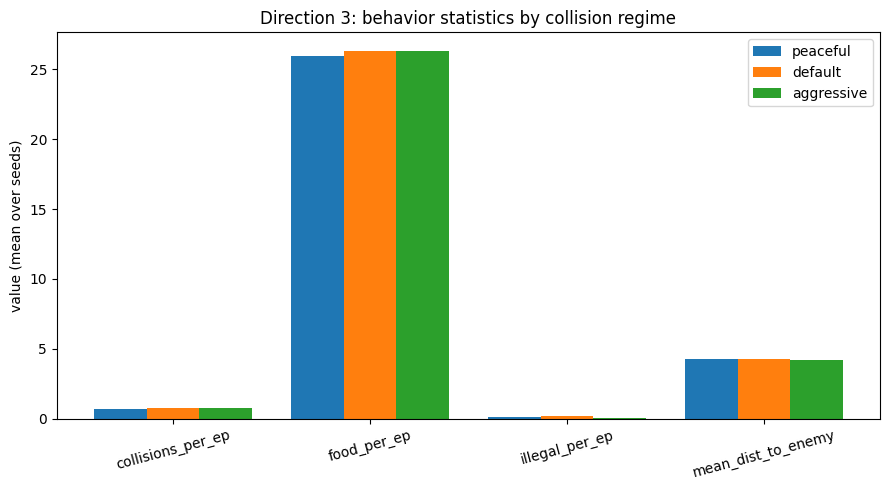

In [13]:
stat_keys = ["collisions_per_ep", "food_per_ep", "illegal_per_ep", "mean_dist_to_enemy"]
x = np.arange(len(stat_keys))
width = 0.8 / len(REGIMES)

plt.figure(figsize=(9, 5))
for i, regime in enumerate(REGIMES):
    means = [np.mean([regime_stats[(regime, seed)][k] for seed in SEEDS]) for k in stat_keys]
    plt.bar(x + i * width, means, width=width, label=regime)
plt.xticks(x + width * (len(REGIMES) - 1) / 2, stat_keys, rotation=15)
plt.ylabel("value (mean over seeds)")
plt.title("Direction 3: behavior statistics by collision regime")
plt.legend()
plt.tight_layout()
plt.show()

## Extension: potential-based shaping on the default regime

We now train the `default` regime both with and without potential-based shaping and compare
learning curves and final win rate. Per Ng et al. (1999), shaping is expected to produce **faster**
learning (a steeper/earlier-rising curve) while converging to an **equivalent policy** — so the
final win rate (measured with the plain, unshaped `GymWrapper` / `play_match`, since shaping is only
ever a training-time signal) should be statistically indistinguishable between the shaped and
unshaped agents, even though the shaped agent may reach that win rate in less training time.


In [14]:
shaping_models, shaping_curves = {}, {}
for seed in SEEDS:
    for shaped in (False, True):
        env = GymWrapper(CONFIG, RandomOpponent(), shaping=shaped)
        model, rewards = train_dqn_on(env, TIMESTEPS, seed, LEARNING_STARTS)
        shaping_models[(shaped, seed)] = model
        shaping_curves[(shaped, seed)] = rewards
        # Evaluation always uses the plain (unshaped) GymWrapper/play_match win_rate: shaping only
        # ever touches the training reward, never the evaluation metric (Ng et al. invariance).
        wr = win_rate(CONFIG, PolicySnapshotOpponent(model), RandomOpponent(), EVAL_GAMES)
        save_result(3, "shaping", {"shaped": shaped}, seed,
                    {"vs_random": wr, "curve_tail_mean": float(np.mean(rewards[-20:]))})
        print("shaped" if shaped else "unshaped", seed, wr)

saved -> results\direction3_shaping.json (1 records)
unshaped 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction3_shaping.json (2 records)
shaped 0 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}
saved -> results\direction3_shaping.json (3 records)
unshaped 1 {'win': 0.98, 'draw': 0.0, 'loss': 0.02}
saved -> results\direction3_shaping.json (4 records)
shaped 1 {'win': 1.0, 'draw': 0.0, 'loss': 0.0}


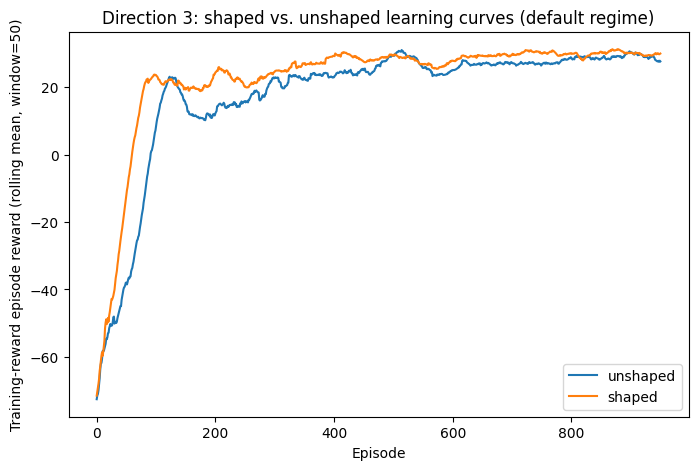

In [15]:
def rolling_mean(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < 1:
        return x
    w = min(window, len(x))
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8, 5))
for shaped in (False, True):
    per_seed = [rolling_mean(shaping_curves[(shaped, seed)]) for seed in SEEDS]
    min_len = min(len(c) for c in per_seed) if per_seed else 0
    if min_len == 0:
        continue
    stacked = np.stack([c[:min_len] for c in per_seed])
    mean_curve = stacked.mean(axis=0)
    x = np.arange(min_len)
    plt.plot(x, mean_curve, label="shaped" if shaped else "unshaped")
plt.xlabel("Episode")
plt.ylabel("Training-reward episode reward (rolling mean, window=50)")
plt.title("Direction 3: shaped vs. unshaped learning curves (default regime)")
plt.legend()
plt.show()
# Note: the shaped curve's y-axis includes the potential-based bonus term, so the two curves are
# not directly comparable in raw magnitude -- what matters is how quickly each rises, not the
# absolute reward level. Win rate (evaluated unshaped, above) is the fair comparison of policy quality.

In [16]:
best_path = ARTIFACTS_DIR / "direction3_best.zip"
regime_models[("default", SEEDS[0])].save(best_path)
(ARTIFACTS_DIR / "direction3_best.meta.json").write_text(json.dumps({"encoder": "vec8", "n": 8}))
print(f"saved best agent -> {best_path}")

saved best agent -> artifacts\direction3_best.zip


## Conclusion

The results above are from **course-scale** runs (short training, few seeds, few eval/behavior
episodes) and should be read as **directional trends**, not final numbers — variance across seeds
is expected to be substantial at this scale.

What to look for:
- **Part A (regimes)**: whether `aggressive` training yields a measurably higher
  `collisions_per_ep` and lower `mean_dist_to_enemy` than `peaceful` (i.e. the agent learns to seek
  out the opponent when collisions are lucrative), and whether `peaceful` yields the highest
  `food_per_ep` (no incentive to interact with the opponent, more focus purely on food).
- **Part B (shaping)**: whether the shaped agent's episode-reward curve rises faster/earlier than
  the unshaped one, while the final `vs_random` win rates (both measured on the plain, unshaped
  evaluation) end up close to each other — supporting Ng et al.'s policy-invariance claim at this
  small scale.

For full-scale runs (see the config cell's full-scale comments: `TIMESTEPS`, `SEEDS`, `EVAL_GAMES`,
`REGIMES` with 2 additional intermediate regimes, and `BEHAVIOR_EPISODES`), rerun this notebook
end-to-end with those constants substituted in; more seeds, eval games, and behavior episodes make
both the win-rate estimates and the behavior-statistic means more reliable.
